## Core collapse SN 2019ehk in NGC4321

In [486]:
import sys
import os

sys.path.append(os.path.abspath(".."))

import functions
import importlib
importlib.reload(functions)

from functions import *
from astropy.io import fits

In [500]:
file_path = '../../DATA/SN2011jm/'
# '../../DATA/SN2019ehk/'

na_rest=(5890+5896)/2
K_I = 7699
DIB_I = 8621
DIB_II = 8648
central_wavelength = na_rest

index=findWavelengths(wave, central_wavelength)[1]

z=0.003197
#z=0.00525

In [501]:
from astropy.time import Time

def to_jd(year, month, day, hour=0, minute=0, second=0):
    date = f"{year:04d}-{month:02d}-{day:02d}T{hour:02d}:{minute:02d}:{second:02d}"
    return Time(date, format="isot").jd

In [502]:
index=findWavelengths(wave, central_wavelength*(1+z))[1]
cube[index]
np.all(np.isnan(cube[index]))

np.False_

### preparing SN spectra of each epoch

In [326]:
from pathlib import Path

directory = Path(file_path)

filenames = [f.name for f in directory.iterdir() if f.is_file()]

In [327]:
filenames

['2019ehk_2458610.0236_BAO-2.16m_Cassegrain_None.fits',
 '2019ehk_2458604.1332_BAO-2.16m_Cassegrain_None.fits',
 '2019ehk_2458613.0768_BAO-2.16m_Cassegrain_None.fits',
 'SN2019ehk_2019-04-30_06-13-31_Lick-3m_KAST_TNS.dat',
 'SN2019ehk_2019-05-08_23-17-20_P60_SEDM_TNS.ascii',
 '2019ehk_2019-05-13_00-00-00_P200_DBSP_None.txt',
 '2019ehk_2458606.1991_BAO-2.16m_Cassegrain_None.fits',
 'SN2019ehk.fits',
 '2019ehk_2458609.1449_BAO-2.16m_Cassegrain_None.fits',
 '2019ehk_2458608.0076_BAO-2.16m_Cassegrain_None.fits']

storing all SNe epochs spectra into one npz file

In [333]:
spectra = []

reading dat file

In [334]:
file = Path(file_path) / 'SN2019ehk_2019-04-30_06-13-31_Lick-3m_KAST_TNS.dat'

df = pd.read_csv(file, sep=r"\s+", header=None)
x = df.iloc[:, 0].to_numpy()
y = df.iloc[:, 1].to_numpy()
jd = to_jd(2019,4,30,6,13,31)

spectra.append({"file": file,"julian_date": jd,"x": x,"y": y})

reading fits files

In [335]:
fits_files = [f for f in filenames if f.endswith(".fits")]

['2019ehk_2458610.0236_BAO-2.16m_Cassegrain_None.fits',
 '2019ehk_2458604.1332_BAO-2.16m_Cassegrain_None.fits',
 '2019ehk_2458613.0768_BAO-2.16m_Cassegrain_None.fits',
 '2019ehk_2458606.1991_BAO-2.16m_Cassegrain_None.fits',
 'SN2019ehk.fits',
 '2019ehk_2458609.1449_BAO-2.16m_Cassegrain_None.fits',
 '2019ehk_2458608.0076_BAO-2.16m_Cassegrain_None.fits']

In [336]:

for name in fits_files:

    file = Path(file_path) / name
    if name == "SN2019ehk.fits":
        continue
    with fits.open(file) as hdul:
        y = hdul[0].data
        header = hdul[0].header
        
        NAXIS = int(header["NAXIS1"])
        CRVAL = float(header["CRVAL1"])
        CDELT = float(header["CDELT1"])
        CRPIX = float(header["CRPIX1"])
        x = CRVAL + CDELT * (np.arange(NAXIS) + 1 - CRPIX)
        jd = header["JD"]
    if int(float(jd)) > 2458700:
        continue
    spectra.append({"file": file,"julian_date": jd,"x": x,"y": y})

reading ascii files

In [337]:
file = Path(file_path) / 'SN2019ehk_2019-05-08_23-17-20_P60_SEDM_TNS.ascii'

data = np.loadtxt(file, comments="#")

x = data[:, 0]
y = data[:, 1]
jd = to_jd(2019,5,8,23,17,20)

spectra.append({"file": file,"julian_date": jd,"x": x,"y": y})

reading txt files

In [338]:
file = Path(file_path) / "2019ehk_2019-05-13_00-00-00_P200_DBSP_None.txt"


data = np.loadtxt(file, comments="#")

x = data[:, 0]
y = data[:, 1]
jd = to_jd(2019,5,13,0,0,0)

spectra.append({"file": file,"julian_date": jd,"x": x,"y": y})

In [339]:
len(spectra)

8

In [340]:
np.save("spectra.npy", spectra, allow_pickle=True)

### measuring EW for each epoch

../../DATA/SN2019ehk/SN2019ehk_2019-04-30_06-13-31_Lick-3m_KAST_TNS.dat
The wrong flux error was  0.9999999999999999


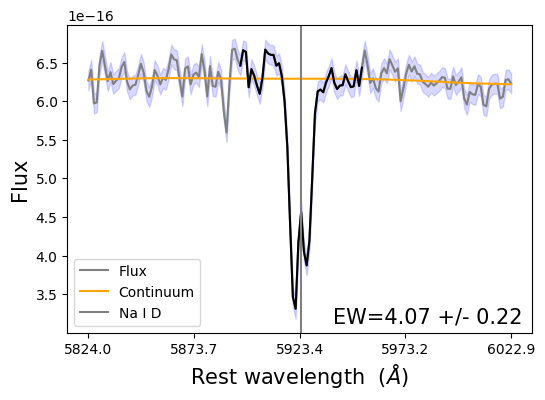


EW= 4.07  +/-  0.21885940151523353

Node separation =  159.11999999999972  Angstrom
SNR of the line is  18.605877852688312
../../DATA/SN2019ehk/2019ehk_2458610.0236_BAO-2.16m_Cassegrain_None.fits
The wrong flux error was  0.9999999999999999


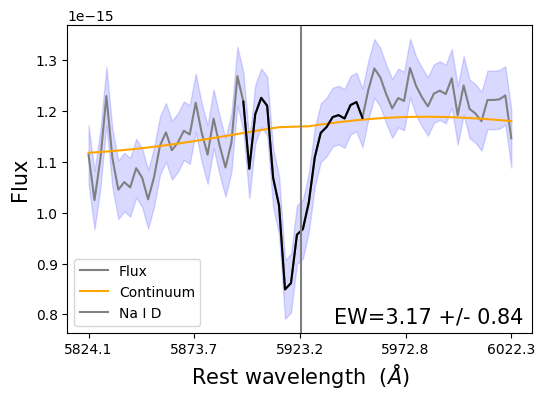


EW= 3.17  +/-  0.8377049387244727

Node separation =  295.87981233099566  Angstrom
SNR of the line is  3.789677502104205
../../DATA/SN2019ehk/2019ehk_2458613.0768_BAO-2.16m_Cassegrain_None.fits
The wrong flux error was  0.9999999999999999


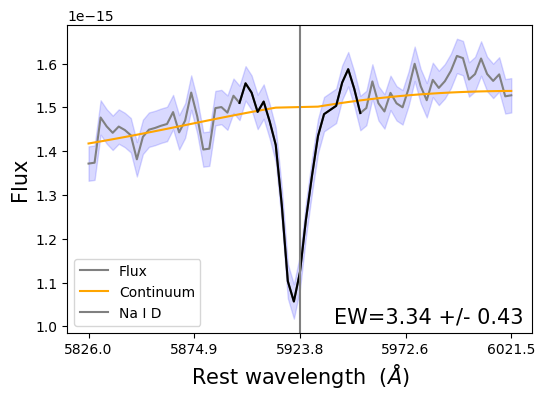


EW= 3.34  +/-  0.4273518995004611

Node separation =  305.36177608103117  Angstrom
SNR of the line is  7.825010211800549
../../DATA/SN2019ehk/2019ehk_2458606.1991_BAO-2.16m_Cassegrain_None.fits
The wrong flux error was  0.9999999999999999


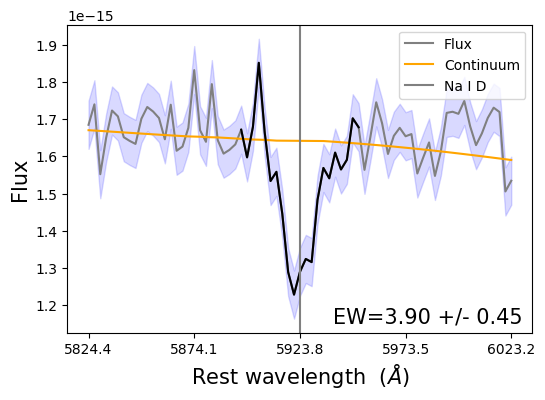


EW= 3.90  +/-  0.4461897923890766

Node separation =  320.76152945428623  Angstrom
SNR of the line is  8.73956926257312
../../DATA/SN2019ehk/2019ehk_2458609.1449_BAO-2.16m_Cassegrain_None.fits
The wrong flux error was  0.9999999999999999


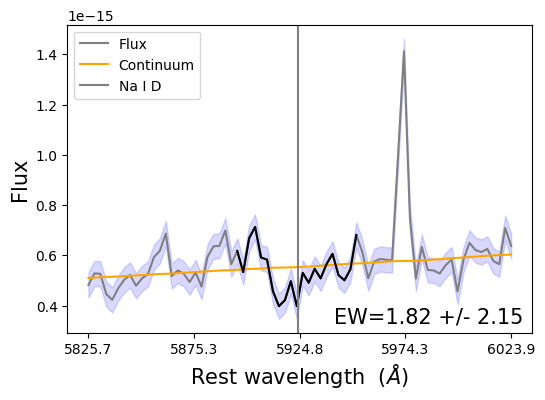


EW= 1.82  +/-  2.1486391822777287

Node separation =  335.812954843607  Angstrom
SNR of the line is  0.8467183822635761
../../DATA/SN2019ehk/2019ehk_2458608.0076_BAO-2.16m_Cassegrain_None.fits
The wrong flux error was  0.9999999999999999


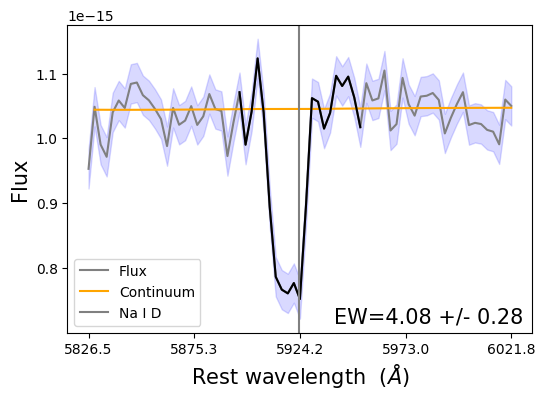


EW= 4.08  +/-  0.2816249179688651

Node separation =  315.6118724506429  Angstrom
SNR of the line is  14.487462616359126
../../DATA/SN2019ehk/SN2019ehk_2019-05-08_23-17-20_P60_SEDM_TNS.ascii
The wrong flux error was  0.5808450537963584


ValueError: The number of derivatives at boundaries does not match: expected 1, got 0+0

In [395]:
spectra = np.load("spectra.npy", allow_pickle=True)

ews = []
ews_uncs = []
jds = []
for spec in spectra:
    
    print(spec["file"])
    x = spec["x"]
    y = spec["y"]

    if central_wavelength*(1+z)>np.max(x) or central_wavelength*(1+z)<np.min(x):
        continue
    
    ew,ew_unc,foo=EW_voronoi_bins(np.array([y]),x,central_wavelength*(1+z),v=1500,KS=100,plots=True)
    
    ews.append(ew[0])
    ews_uncs.append(ew_unc[0])
    jds.append(spec["julian_date"])

In [383]:
jds

[np.float64(2458603.759386574),
 '2458610.0236',
 '2458613.0768',
 '2458606.1991',
 '2458609.1449',
 '2458608.0076']

Text(0, 0.5, 'Spectrum EW measurement')

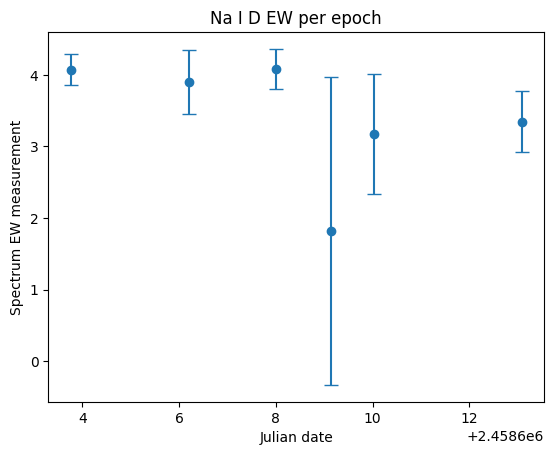

In [398]:
plt.errorbar(jds, ews, yerr=ews_uncs, fmt='o', capsize=5)
plt.title("Na I D EW per epoch")
plt.xlabel("Julian date")
plt.ylabel("Spectrum EW measurement")

In [51]:
#df = pd.read_csv(file_path+filenames[0], sep=r"\s+", header=None)

In [52]:
x = df.iloc[:, 0].to_numpy()
y = df.iloc[:, 1].to_numpy()

NEW MAR2026 KS IS  100
The wrong flux error was  0.9999999999999999
The corrected flux error now is  2.6028092360069325e-17


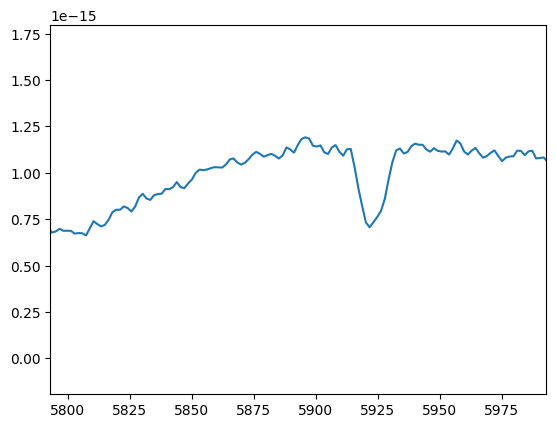

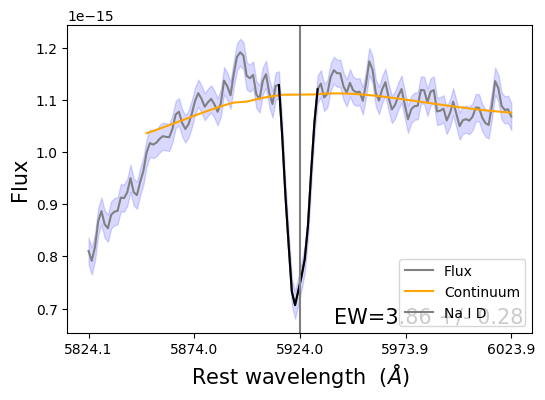


EW= 3.86  +/-  0.27538032503811477

Node separation =  170.61881188118795  Angstrom
SNR of the line is  14.03469164753357


([np.float64(3.8648779477075093)],
 [np.float64(0.27538032503811477)],
 [np.float64(8640.475542491751)])

In [102]:
plt.plot(x,y)
plt.xlim(central_wavelength-100,central_wavelength+100)
#plt.axvline(x=central_wavelength*(1+z),color='red')

EW_voronoi_bins(np.array([y]),x,central_wavelength*(1+z),v=500,KS=100,plots=True)


## MUSE data

In [503]:
data = fits.open(file_path+"SN2011jm.fits")#"SN2019ehk.fits")
cube = data[1].data   # this is the cube, a (3681 x 341 x 604) matrix with fluxes at different 3681 wavelengths and 308 x 318 spatial pixels ("spaxels")

header = data[1].header # this has information on the data cube
ecube = data[2].data # this is the cube uncertainty (3681 x 341 x 604)


x_len=len(cube[0][0])
y_len=len(cube[0])



#  -- following is to the get the wavelength array
CRVAL = float(header["CRVAL3"])
NAXIS = int(header["NAXIS3"])
CDELT = float(header["CD3_3"])
CRPIX = float(header["CRPIX3"])
wave = np.array(CRVAL + CDELT * (np.arange(NAXIS) - CRPIX))

In [504]:
stacked_cube=np.nanmedian(cube[int(len(wave)/4):int(3*len(wave)/4),:,:], axis=0)##i was doing sum

/home/ritapsantos/PhD/extinction-ifs/env-extinction/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,


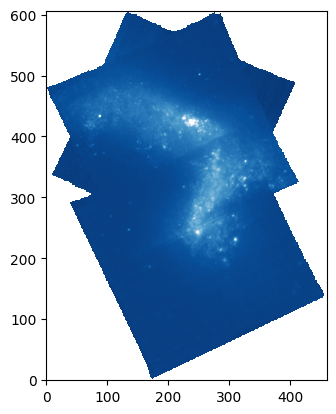

In [505]:
lo,up = np.nanpercentile(stacked_cube,0.05),np.nanpercentile(stacked_cube,99.95)
plt.imshow(stacked_cube, cmap='Blues_r', origin='lower',clim=(lo,up))

In [506]:
wcs = WCS(data[1].header)
print(wcs)

WCS Keywords

Number of WCS axes: 3
CTYPE : 'RA---TAN' 'DEC--TAN' 'AWAV'
CUNIT : 'deg' 'deg' 'm'
CRVAL : 193.714583 2.65278 4.74968798828125e-07
CRPIX : 209.3617494060399 401.7102987937627 1.0
CD1_1 CD1_2 CD1_3  : -5.55555555555556e-05 0.0 0.0
CD2_1 CD2_2 CD2_3  : 0.0 5.55555555555556e-05 0.0
CD3_1 CD3_2 CD3_3  : 0.0 0.0 1.25e-10
NAXIS : 461  607  3681


  'angstrom' -> 'Angstrom'. [astropy.wcs.wcs]


In [507]:
from astropy.wcs import WCS
from astropy.io import fits


# getting just the 2D celestial (RA/Dec) part of the WCS
wcs_2d = wcs.celestial


In [508]:

ra_sn = 193.713#185.733958
dec_sn = 2.65414#15.826119

# origin=0 -> numpy/python convention (0-indexed pixels)
x, y = wcs_2d.all_world2pix(ra_sn, dec_sn, 0)

print(x, y)
x=int(x)
y=int(y)

236.82518274980194 425.19031700619996


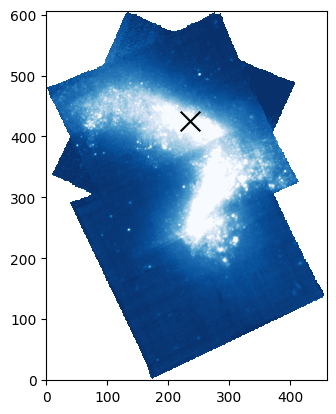

In [509]:
lo,up = np.nanpercentile(stacked_cube,0.05),np.nanpercentile(stacked_cube,99.95)
lo,up = np.nanpercentile(stacked_cube,5),np.nanpercentile(stacked_cube,95)
plt.imshow(stacked_cube, cmap='Blues_r', origin='lower',clim=(lo,up))


plt.scatter(x,y,marker='x',color='black',s=200)

Valid pixels count:  317


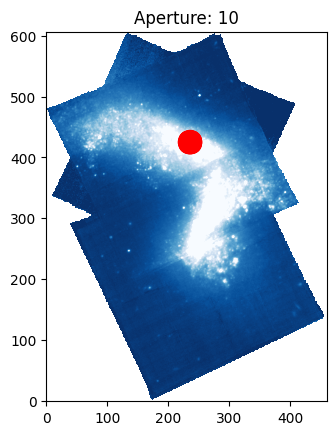

[22590.328 22714.58  22715.139 22538.287 22012.42  22791.322 22749.508
 22712.629 22366.428 22465.799 22535.56  22192.781 22105.127 22036.697
 22414.75  22638.654 22716.53  22853.578 22654.398 22488.166 22380.076
 22436.607 21971.438 22360.504 22800.625 22701.357 22564.45  22633.8
 22508.611 22069.86  22315.453 22289.387 22424.629 22558.164 22206.969
 22254.41  21964.646 22124.395 22382.705 22440.543 22447.877 22544.248
 22349.627 22435.762 22761.197 22124.    22365.879 22544.025 22275.686
 22053.13  22631.484 22260.436 22291.533 22403.953 22365.9   22630.195
 22236.    22550.887 22665.559 22423.383 22643.107 22293.209 21882.525
 21906.186 21696.43  22013.    21498.387 21535.84  21343.072 21646.5
 21120.266 21324.152 21565.574 22043.258 21684.332 21763.87  21997.879
 21764.252 21632.895 21155.86  20818.873 18529.41  19120.309 23741.014
 42981.305 64820.28  48479.445 24977.727 21322.715 21545.186 21071.168
 21181.926 21360.12  21888.693 21441.709 21366.342 19964.44  20374.248
 20617.105

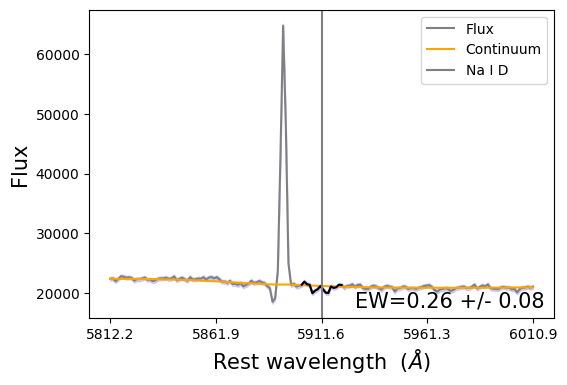


EW= 0.26  +/-  0.08495481925716718

Node separation =  130.75657894736844  Angstrom
SNR of the line is  3.098131367228273


In [511]:
ap=10
spec_ap,pixels=circular_aperture_sum(cube[index-100:index+100,:,:],x,y, radius=ap)

lo,up = np.nanpercentile(stacked_cube,5),np.nanpercentile(stacked_cube,95)
plt.imshow(stacked_cube, cmap='Blues_r', origin='lower',clim=(lo,up))

 
#plot aperture region
x_ap,y_ap = zip(*pixels)
plt.scatter(x_ap,y_ap, facecolors='none', edgecolors='red', s=60, linewidths=1.5, alpha=0.8)
plt.title(f"Aperture: {ap}")
plt.show()

print(spec_ap)
out=EW_voronoi_bins(np.asarray([spec_ap]),wave[index-100:index+100],central_wavelength*(1+z),v=500,KS=100,plots=True)

(18000.0, 30000.0)

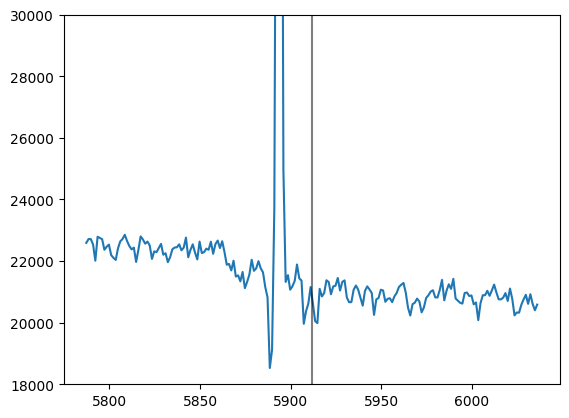

In [519]:
plt.plot(wave[index-100:index+100],spec_ap)
plt.axvline(x=na_rest*(1+z),alpha=0.5,color="black")
plt.ylim(18000,30000)

In [528]:
import pandas as pd



df = pd.read_csv("../../DATA/SN2011jm/SN_2011jm_2012-02-02_10-19-12_Lick-3m_KAST_UCB-SNDB_0.flm", sep=r"\s+", header=None)

            0         1         2
0      3444.0  0.355811  0.150399
1      3446.0  0.427993  0.152729
2      3448.0  0.267422  0.151992
3      3450.0  0.259128  0.154231
4      3452.0  0.491634  0.155685
...       ...       ...       ...
3401  10246.0  0.101285  0.110275
3402  10248.0  0.059413  0.112579
3403  10250.0  0.069482  0.114266
3404  10252.0  0.094193  0.115900
3405  10254.0  0.091655  0.115753

[3406 rows x 3 columns]


The wrong flux error was  1.0000619647765359


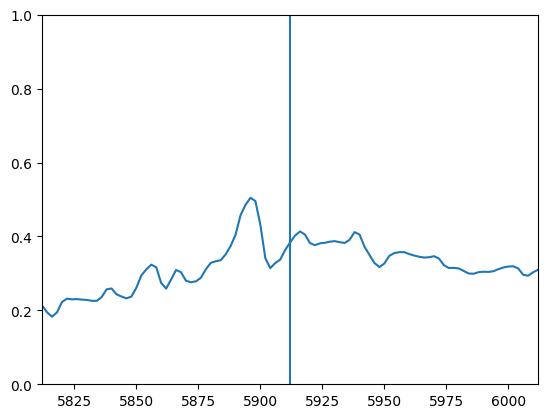

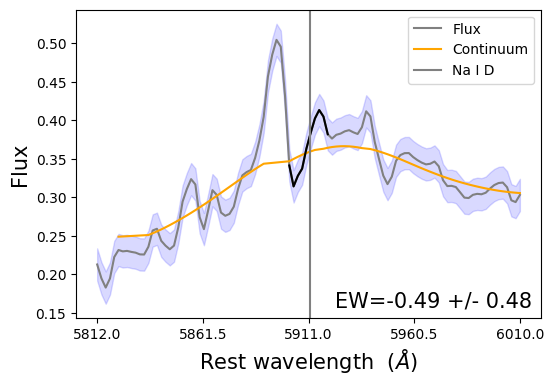


EW= -0.49  +/-  0.4752435284452159

Node separation =  116.0493827160494  Angstrom
SNR of the line is  -1.0304892502401097


([np.float64(-0.4897333473089748)],
 [np.float64(0.4752435284452159)],
 [np.float64(5888.998227293987)])

In [539]:
x = df.iloc[:, 0].to_numpy()
y = df.iloc[:, 1].to_numpy()

plt.plot(x,y)
plt.xlim(na_rest*(1+z)-100,na_rest*(1+z)+100)
plt.axvline(x=na_rest*(1+z))
plt.ylim(0,1)

EW_voronoi_bins(np.asarray([y]),x,central_wavelength*(1+z),v=500,KS=50,plots=True)

In [531]:
x

array([ 3444.,  3446.,  3448., ..., 10250., 10252., 10254.], shape=(3406,))

In [ ]:
------- what i had before:

In [ ]:
wcs = WCS(data[1].header) 

center_x=int(x_len/2)
center_y=int(y_len/2)

?????ra, dec, _ = wcs.all_pix2world(center_x, center_y, 0, 0)

#print(ra,dec)

ra_degrees=185.733958
dec_degrees=15.826119
print("SN occured at ",ra_degrees, dec_degrees)

In [ ]:
#atenção, changed the code here so x is rest wavelength, that is, wave/(1+z)

spec_diff_apertures=[]

for ap in apertures:
    
    y,pixels=circular_aperture_sum(cube[index-100:index+100,:,:],x_nearest,y_nearest, radius=ap)#aqui_sum
    spec_diff_apertures.append(y)
    
    lo,up = np.nanpercentile(cube[index],2),np.nanpercentile(cube[index],98)
    plt.figure(figsize=(10, 8))
    plt.imshow(cube[index],cmap='Blues_r',origin='lower',clim=(lo,up))
    
    #plot aperture region
    x,y = zip(*pixels)
    plt.scatter(x,y, facecolors='none', edgecolors='red', s=60, linewidths=1.5, alpha=0.8)
    plt.title(f"Aperture: {ap}")
    plt.show()
    
out=EW_voronoi_bins(np.array(spec_diff_apertures),np.divide(wave[index-100:index+100],1+z),central_wavelength,v=velocity_window,KS=kernel_size,plots=True,titles=apertures)#central_wavelength*(1+z),v=600,KS=90,plots=True)